In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import amp
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import pandas as pd
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Classifying Galaxies <a id="introduction"></a>

Now that we know how convolutional neural networks operate, let's use them to classify galaxies. Start by loading in your favorite galactic dataset, we'll use Galaxy Zoo 2.

In [2]:
from galaxy_datasets.pytorch import GZ2

train_dataset = GZ2(
    root='data/gz2',
    train=True,
    download=True,
)

train_total = len(train_dataset)
train_df = pd.read_parquet('data/gz2/gz2_train_catalog.parquet') #To get the labels, for some reason not included directly in the dataset
train_labels = train_df['summary'].fillna('undetermined')

test_dataset = GZ2(
    root='data/gz2',
    train=False,
    download=False
)

test_total = len(test_dataset)
test_df = pd.read_parquet('data/gz2/gz2_test_catalog.parquet')
test_labels = test_df['summary'].fillna('undetermined')

c:\Users\Jon\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping


Let's take a look at the data. Run the cell below a few times.

{'id_str': np.int64(587741602572468407), 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=424x424 at 0x168E2BEF110>, 'smooth-or-featured-gz2_smooth': np.int64(37), 'smooth-or-featured-gz2_featured-or-disk': np.int64(0), 'smooth-or-featured-gz2_artifact': np.int64(1), 'disk-edge-on-gz2_yes': np.int64(0), 'disk-edge-on-gz2_no': np.int64(0), 'has-spiral-arms-gz2_yes': np.int64(0), 'has-spiral-arms-gz2_no': np.int64(0), 'bar-gz2_yes': np.int64(0), 'bar-gz2_no': np.int64(0), 'bulge-size-gz2_dominant': np.int64(0), 'bulge-size-gz2_obvious': np.int64(0), 'bulge-size-gz2_just-noticeable': np.int64(0), 'bulge-size-gz2_no': np.int64(0), 'something-odd-gz2_yes': np.int64(4), 'something-odd-gz2_no': np.int64(33), 'how-rounded-gz2_round': np.int64(32), 'how-rounded-gz2_in-between': np.int64(5), 'how-rounded-gz2_cigar': np.int64(0), 'bulge-shape-gz2_round': np.int64(0), 'bulge-shape-gz2_boxy': np.int64(0), 'bulge-shape-gz2_no-bulge': np.int64(0), 'spiral-winding-gz2_tight': np.int64(0

Text(0.5, 1.0, 'barred_spiral')

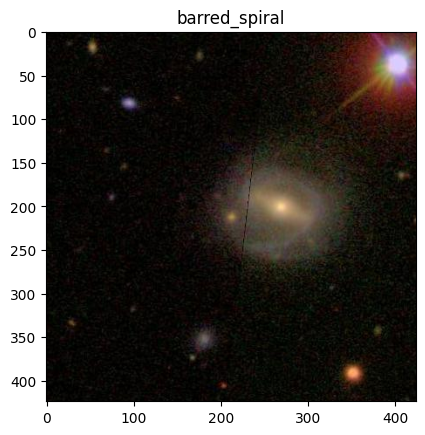

In [15]:
index = np.random.randint(0, train_total)
print(train_dataset[0])
print(f"Item #{index}/{train_total}")
example = train_dataset[index]
keys = list(example.keys())[2:]
for key in keys:
    print(f"{key}: {example[key]}")
plt.figure()
plt.imshow(example['image'])
plt.title(train_labels.iloc[index])

As we can see, the data isn't given an exact classification, but rather vote counts that follow a decision tree. Fortunately, we are given a summary of the votes. Here is a link to the [paper](https://arxiv.org/abs/1308.3496v2) that describes how it works.

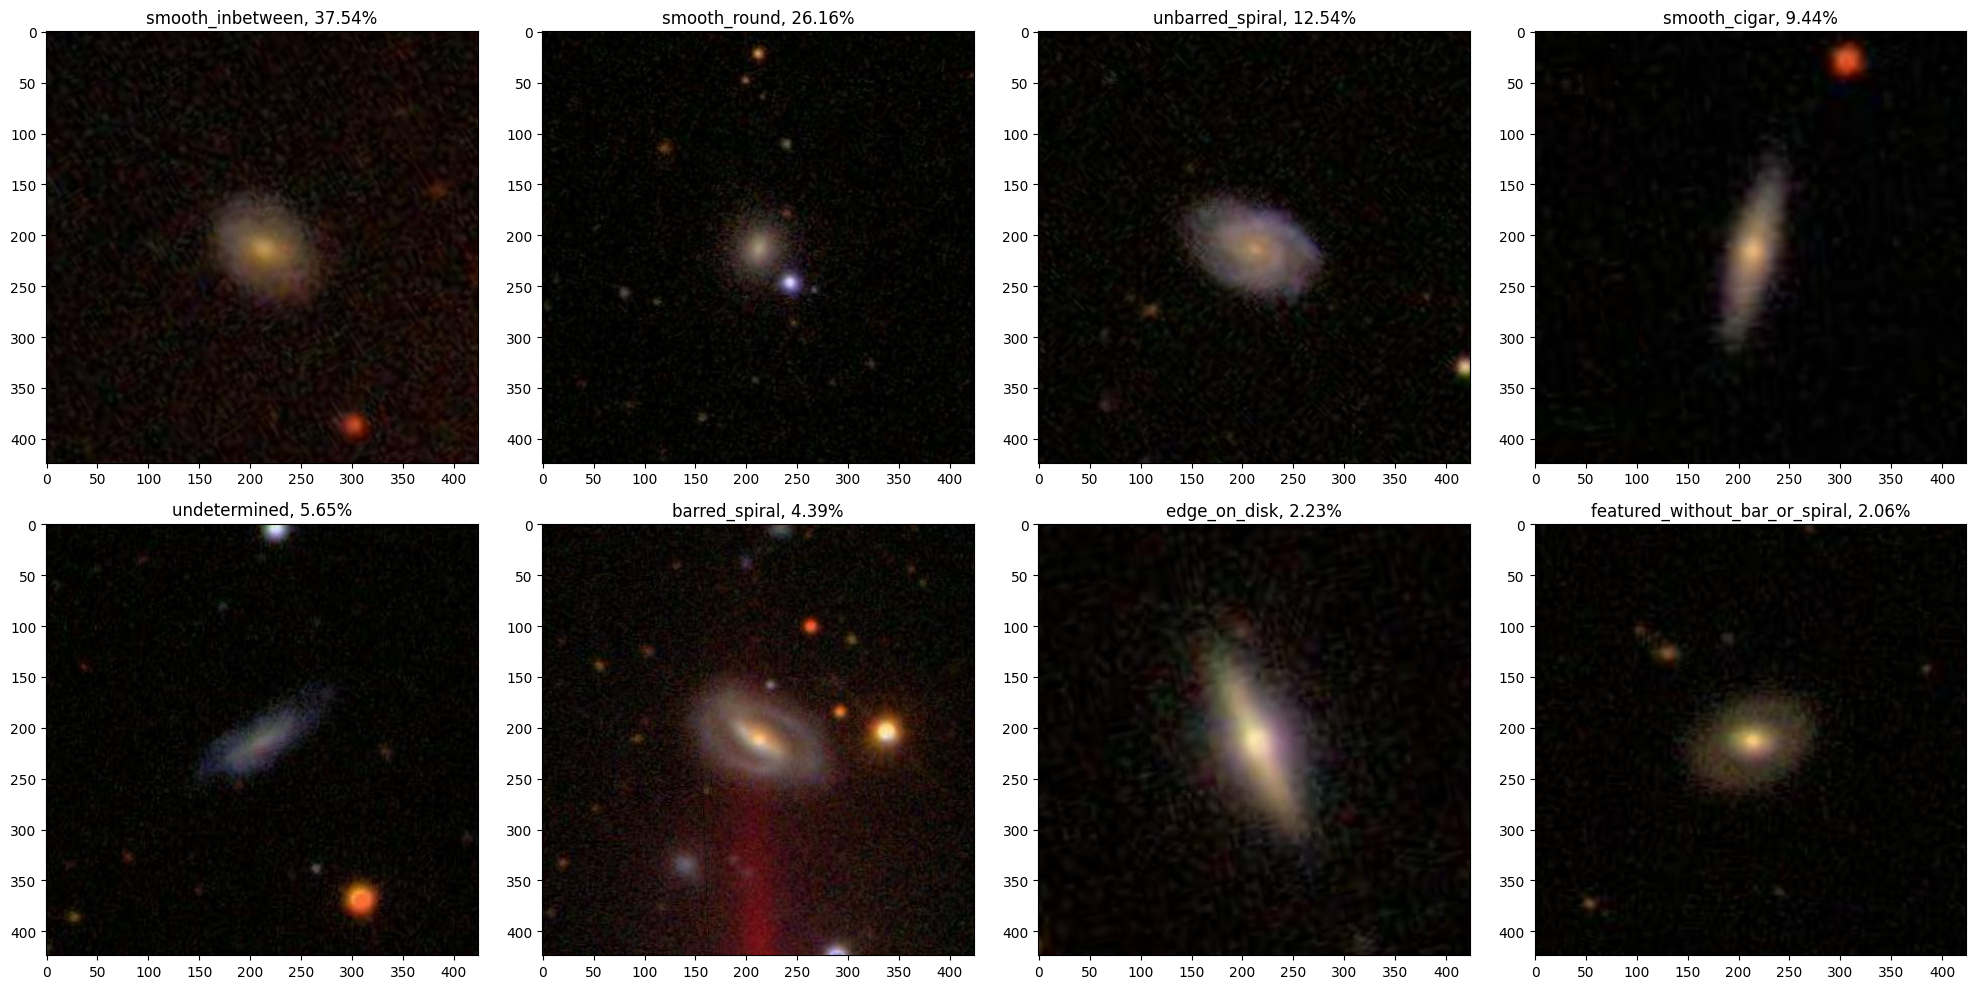

In [16]:
counts = train_labels.value_counts()
plt.figure(figsize=(20, 10), layout='tight')
for i, (label, count) in enumerate(counts.items()):
    examples = np.where(train_labels == label)[0]
    index = np.random.randint(0, len(examples))
    first_example = examples[index]
    plt.subplot(2, 4, i + 1)
    plt.imshow(train_dataset[first_example]['image'])
    plt.title(f"{label}, {100 * count/train_total:.2f}%")

Next we will set up our model. We are using a lot of pooling layers and more to keep the number of parameters down, since these images are large and we have a lot of them.

In [5]:
class GalacticCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.SiLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        self.dropout2d = nn.Dropout2d(0.2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256, 256),
            nn.SiLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.SiLU(inplace=True),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.dropout2d(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = GalacticCNN(num_classes=8)
print("CNN Architecture:")
print(model)
print("\n" + "="*50)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

dummy_input = torch.randn(1, 3, 224, 224)
print(f"\nInput shape: {dummy_input.shape}")

with torch.no_grad():
    out1 = model.block1(dummy_input)
    print(f"After Block1: {out1.shape}")
    out2 = model.block2(out1)
    print(f"After Block2: {out2.shape}")
    out3 = model.block3(out2)
    print(f"After Block3: {out3.shape}")
    gp = model.global_pool(out3)
    print(f"After Global Pool: {gp.shape}")
    flat = gp.view(gp.size(0), -1)
    print(f"After Flatten: {flat.shape}")
    output = model.classifier(flat)
    print(f"After Classifier: {output.shape}")

CNN Architecture:
GalacticCNN(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilati

In this case, our labels are strings and are not part of the dataset itself for some reason, so we will need to modify things a bit before training our model. Also, this dataset is huge, so you may need to cut it down depending on your computer. Change some of the configurations below to make this run better on your hardware, or don't run it and just look at my results. Fortunately for me, I bought my RAM and GPU before AI.

In [6]:
class GalaxyDataset(Dataset):
    def __init__(self, base_dataset, labels):
        self.base_dataset = base_dataset
        self.labels = labels.reset_index(drop=True)
        
        unique_labels = sorted(set(labels))
        self.label_to_idx = {label: i for i, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        sample = self.base_dataset[idx]
        image = sample['image']
        label = self.labels.iloc[idx]
        
        label = self.label_to_idx[label]
        
        label = torch.tensor(label, dtype=torch.long)
        
        return {'image': image, 'label': label}

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('medium')

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset_transformed = GZ2(
    root='data/gz2',
    train=True,
    download=False,
    transform=train_transform
)

test_dataset_transformed = GZ2(
    root='data/gz2',
    train=False,
    download=False,
    transform=test_transform
)

train_dataset_modified = GalaxyDataset(train_dataset_transformed, train_labels)
test_dataset_modified = GalaxyDataset(test_dataset_transformed, test_labels)

train_indices = np.random.choice(len(train_dataset_modified), size=10000, replace=False)
train_dataset_final = Subset(train_dataset_modified, train_indices)

test_indices = np.random.choice(len(test_dataset_modified), size=10000, replace=False)
test_dataset_final = Subset(test_dataset_modified, test_indices)

loader_kwargs = dict(batch_size=32, pin_memory=True, num_workers=0, persistent_workers=False)
train_loader = DataLoader(train_dataset_final, shuffle=True, **loader_kwargs)
test_loader = DataLoader(test_dataset_final, shuffle=False, **loader_kwargs)

Using device: cuda


In [8]:
model = GalacticCNN().to(device)
if device.type == 'cuda':
    model = model.to(memory_format=torch.channels_last)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scaler = amp.GradScaler('cuda', enabled=device.type == 'cuda')

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, sample in enumerate(train_loader):
        images = sample['image'].to(device, non_blocking=True)
        labels = sample['label'].to(device, non_blocking=True)
        if device.type == 'cuda':
            images = images.to(memory_format=torch.channels_last)
        
        optimizer.zero_grad(set_to_none=True)
        with amp.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f'  Training Batch [{batch_idx+1}/{len(train_loader)}], '
                  f'Loss: {loss.item():.4f}, '
                  f'Accuracy: {100 * correct / total:.2f}%')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_idx, sample in enumerate(test_loader):
            images = sample['image'].to(device, non_blocking=True)
            labels = sample['label'].to(device, non_blocking=True)
            if device.type == 'cuda':
                images = images.to(memory_format=torch.channels_last)
            
            with amp.autocast(device_type=device.type, enabled=device.type == 'cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if (batch_idx + 1) % 10 == 0:
                print(f'  Testing Batch [{batch_idx+1}/{len(test_loader)}], '
                      f'Loss: {loss.item():.4f}, '
                      f'Accuracy: {100 * correct / total:.2f}%')
    
    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

num_epochs = 10
train_losses, train_accs = [], []
test_losses, test_accs = [], []
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print("Starting training...")
print("="*60)

for epoch in range(num_epochs):
    print(f'\nEpoch [{epoch+1}/{num_epochs}]')
    print('-' * 60)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    scheduler.step()
    
    print(f'\nEpoch [{epoch+1}/{num_epochs}] Summary:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

print("\n" + "="*60)
print("Training completed!")

Starting training...

Epoch [1/10]
------------------------------------------------------------
  Training Batch [10/313], Loss: 1.7436, Accuracy: 33.44%
  Training Batch [20/313], Loss: 1.8634, Accuracy: 35.94%
  Training Batch [30/313], Loss: 1.6366, Accuracy: 36.98%
  Training Batch [40/313], Loss: 1.6223, Accuracy: 37.27%
  Training Batch [50/313], Loss: 1.6314, Accuracy: 37.00%
  Training Batch [60/313], Loss: 1.5962, Accuracy: 36.67%
  Training Batch [70/313], Loss: 1.4434, Accuracy: 37.99%
  Training Batch [80/313], Loss: 1.5573, Accuracy: 38.83%
  Training Batch [90/313], Loss: 1.6848, Accuracy: 38.72%
  Training Batch [100/313], Loss: 1.7364, Accuracy: 39.03%
  Training Batch [110/313], Loss: 1.5871, Accuracy: 39.23%
  Training Batch [120/313], Loss: 1.7620, Accuracy: 39.19%
  Training Batch [130/313], Loss: 1.6348, Accuracy: 39.09%
  Training Batch [140/313], Loss: 1.4706, Accuracy: 39.06%
  Training Batch [150/313], Loss: 1.4920, Accuracy: 39.31%
  Training Batch [160/313], 

As we can see, we got  over 50% accuracy on a fairly standard model in an hour. It's not perfect, but with the complexity of the data and the hardware I am limited to, I'd say it's pretty good. Furthermore, most galaxies did not have a consensus vote, so the labels aren't perfectly accurate either. Overall, this means we are over 4x as accurate as guessing randomly, and over 15% better than guessing smooth_inbetween every time. Let's take a closer look at the results.

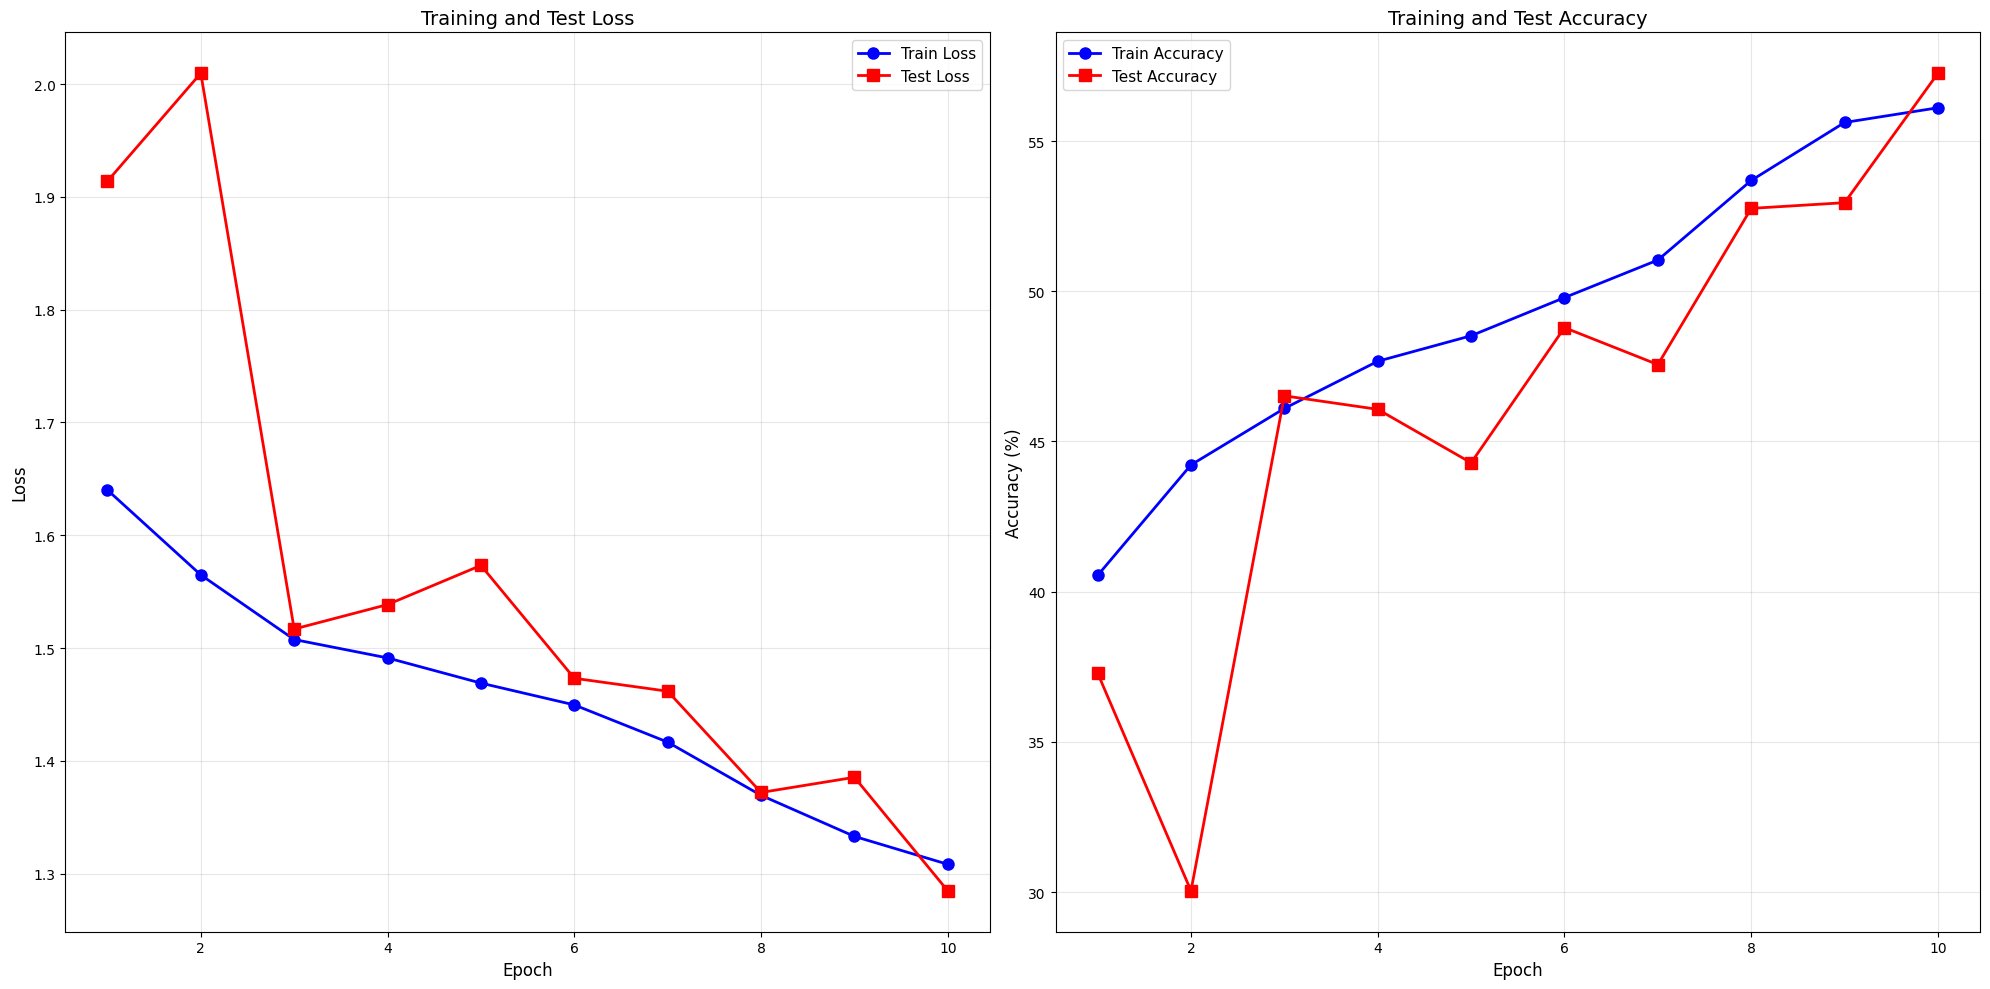

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].plot(range(1, num_epochs+1), train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=8)
axes[0].plot(range(1, num_epochs+1), test_losses, 'r-s', label='Test Loss', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Test Loss', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, num_epochs+1), train_accs, 'b-o', label='Train Accuracy', linewidth=2, markersize=8)
axes[1].plot(range(1, num_epochs+1), test_accs, 'r-s', label='Test Accuracy', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Test Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


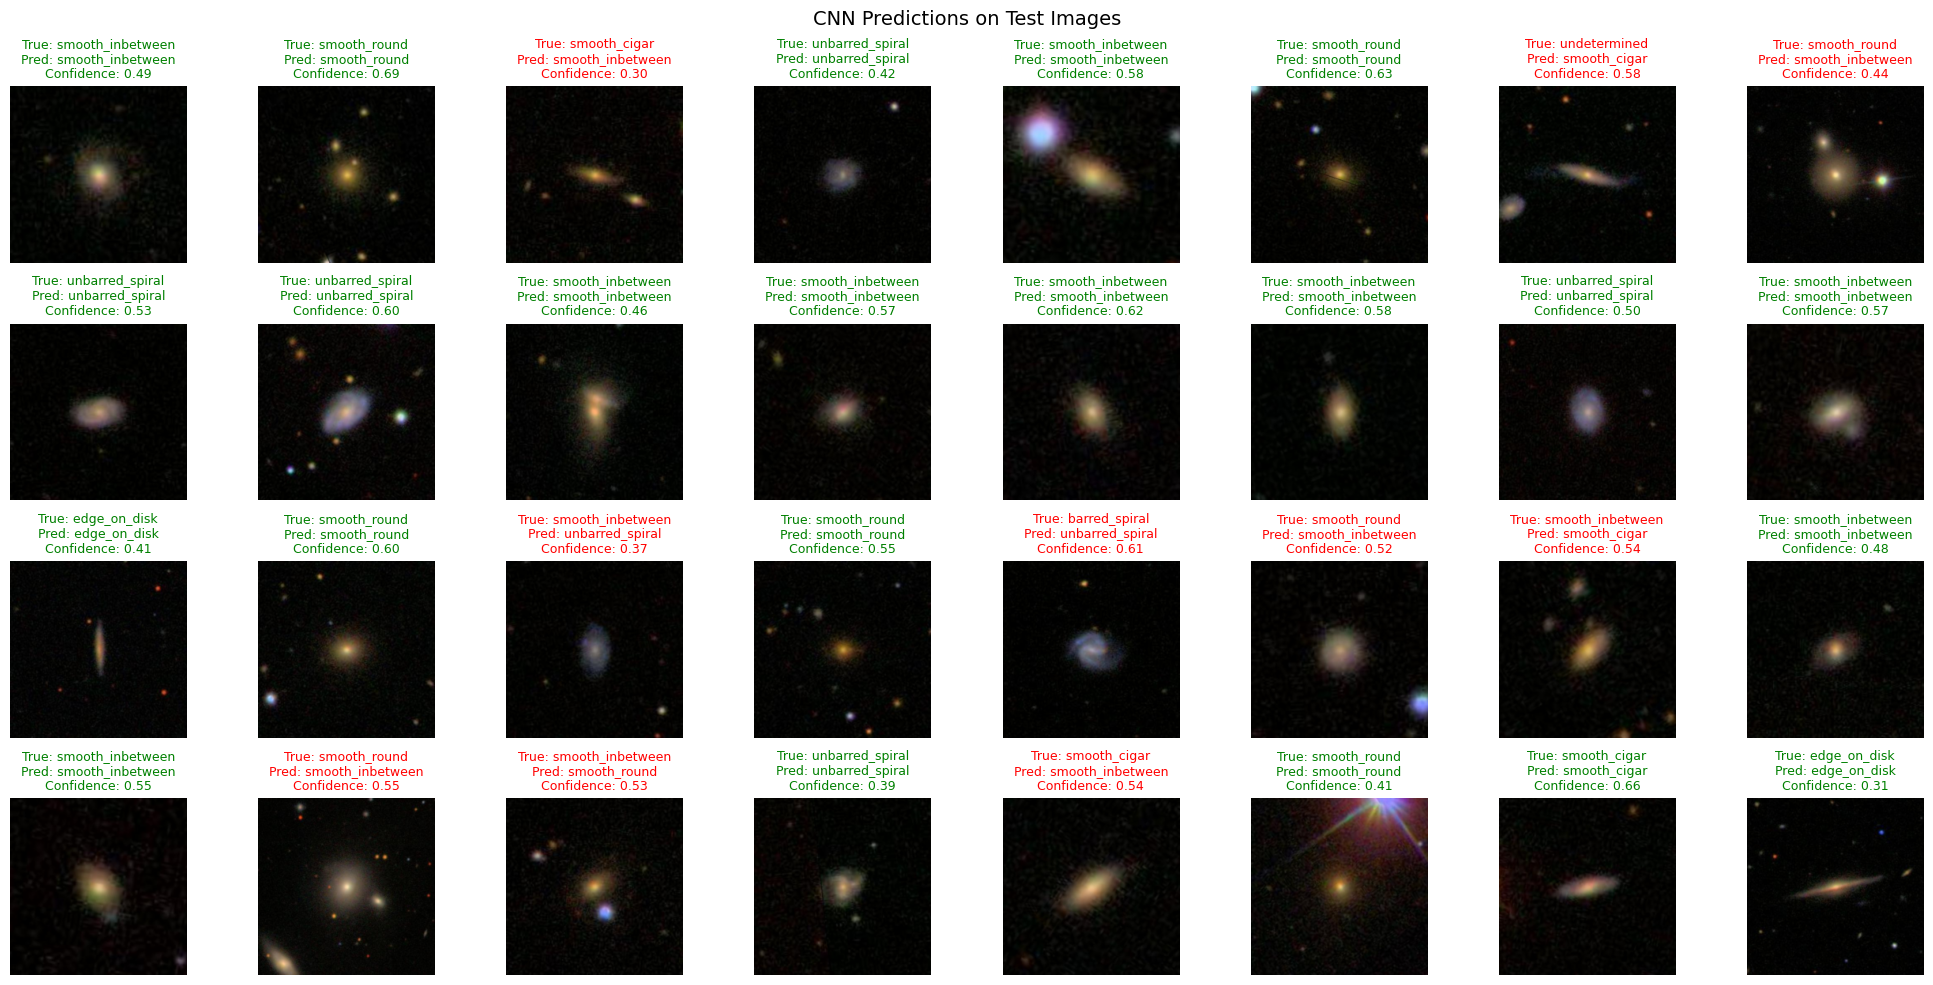

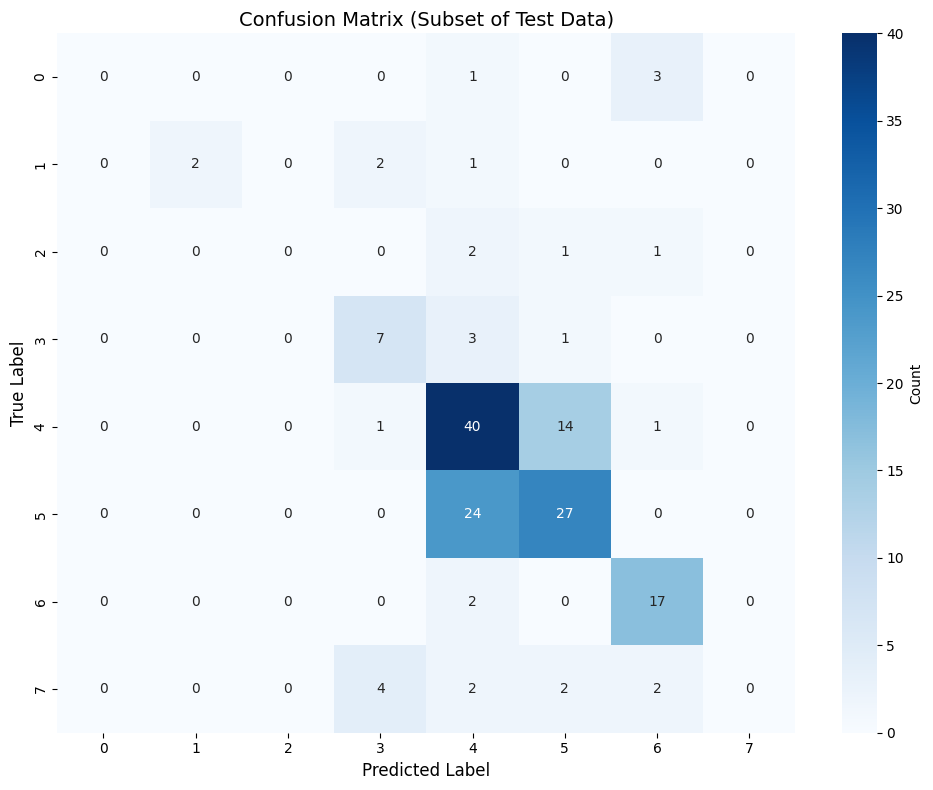

In [30]:
model.eval()
fig, axes = plt.subplots(4, 8, figsize=(20, 10))

dataiter = iter(test_loader)
sample = next(dataiter)
images = sample['image'].to(device, non_blocking=True)
labels = sample['label'].to(device, non_blocking=True)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    probabilities = F.softmax(outputs, dim=1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()
probabilities = probabilities.cpu()
idx_to_label = {v: k for k, v in train_dataset_modified.label_to_idx.items()}

for i in range(32):
    row, col = i // 8, i % 8

    img = images[i].cpu().permute(1, 2, 0)

    img = img * 0.5 + 0.5
    img = img.clamp(0, 1)

    color = 'green' if predicted[i] == labels[i] else 'red'
    axes[row, col].imshow(img.numpy())
    axes[row, col].set_title(
        f'True: {idx_to_label[labels[i].item()]}\nPred: {idx_to_label[predicted[i].item()]}\nConfidence: {probabilities[i][predicted[i]]:.2f}',
        color=color,
        fontsize=9,
    )
    axes[row, col].axis('off')

plt.suptitle('CNN Predictions on Test Images', fontsize=14)
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for sample in list(test_loader)[:5]:  
        images = sample['image'].to(device, non_blocking=True)
        labels = sample['label'].to(device, non_blocking=True)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix (Subset of Test Data)', fontsize=14)
plt.tight_layout()
plt.show()


To the models credit, the one galaxy labeled undetermined in the above sample does look quite cigar shaped.

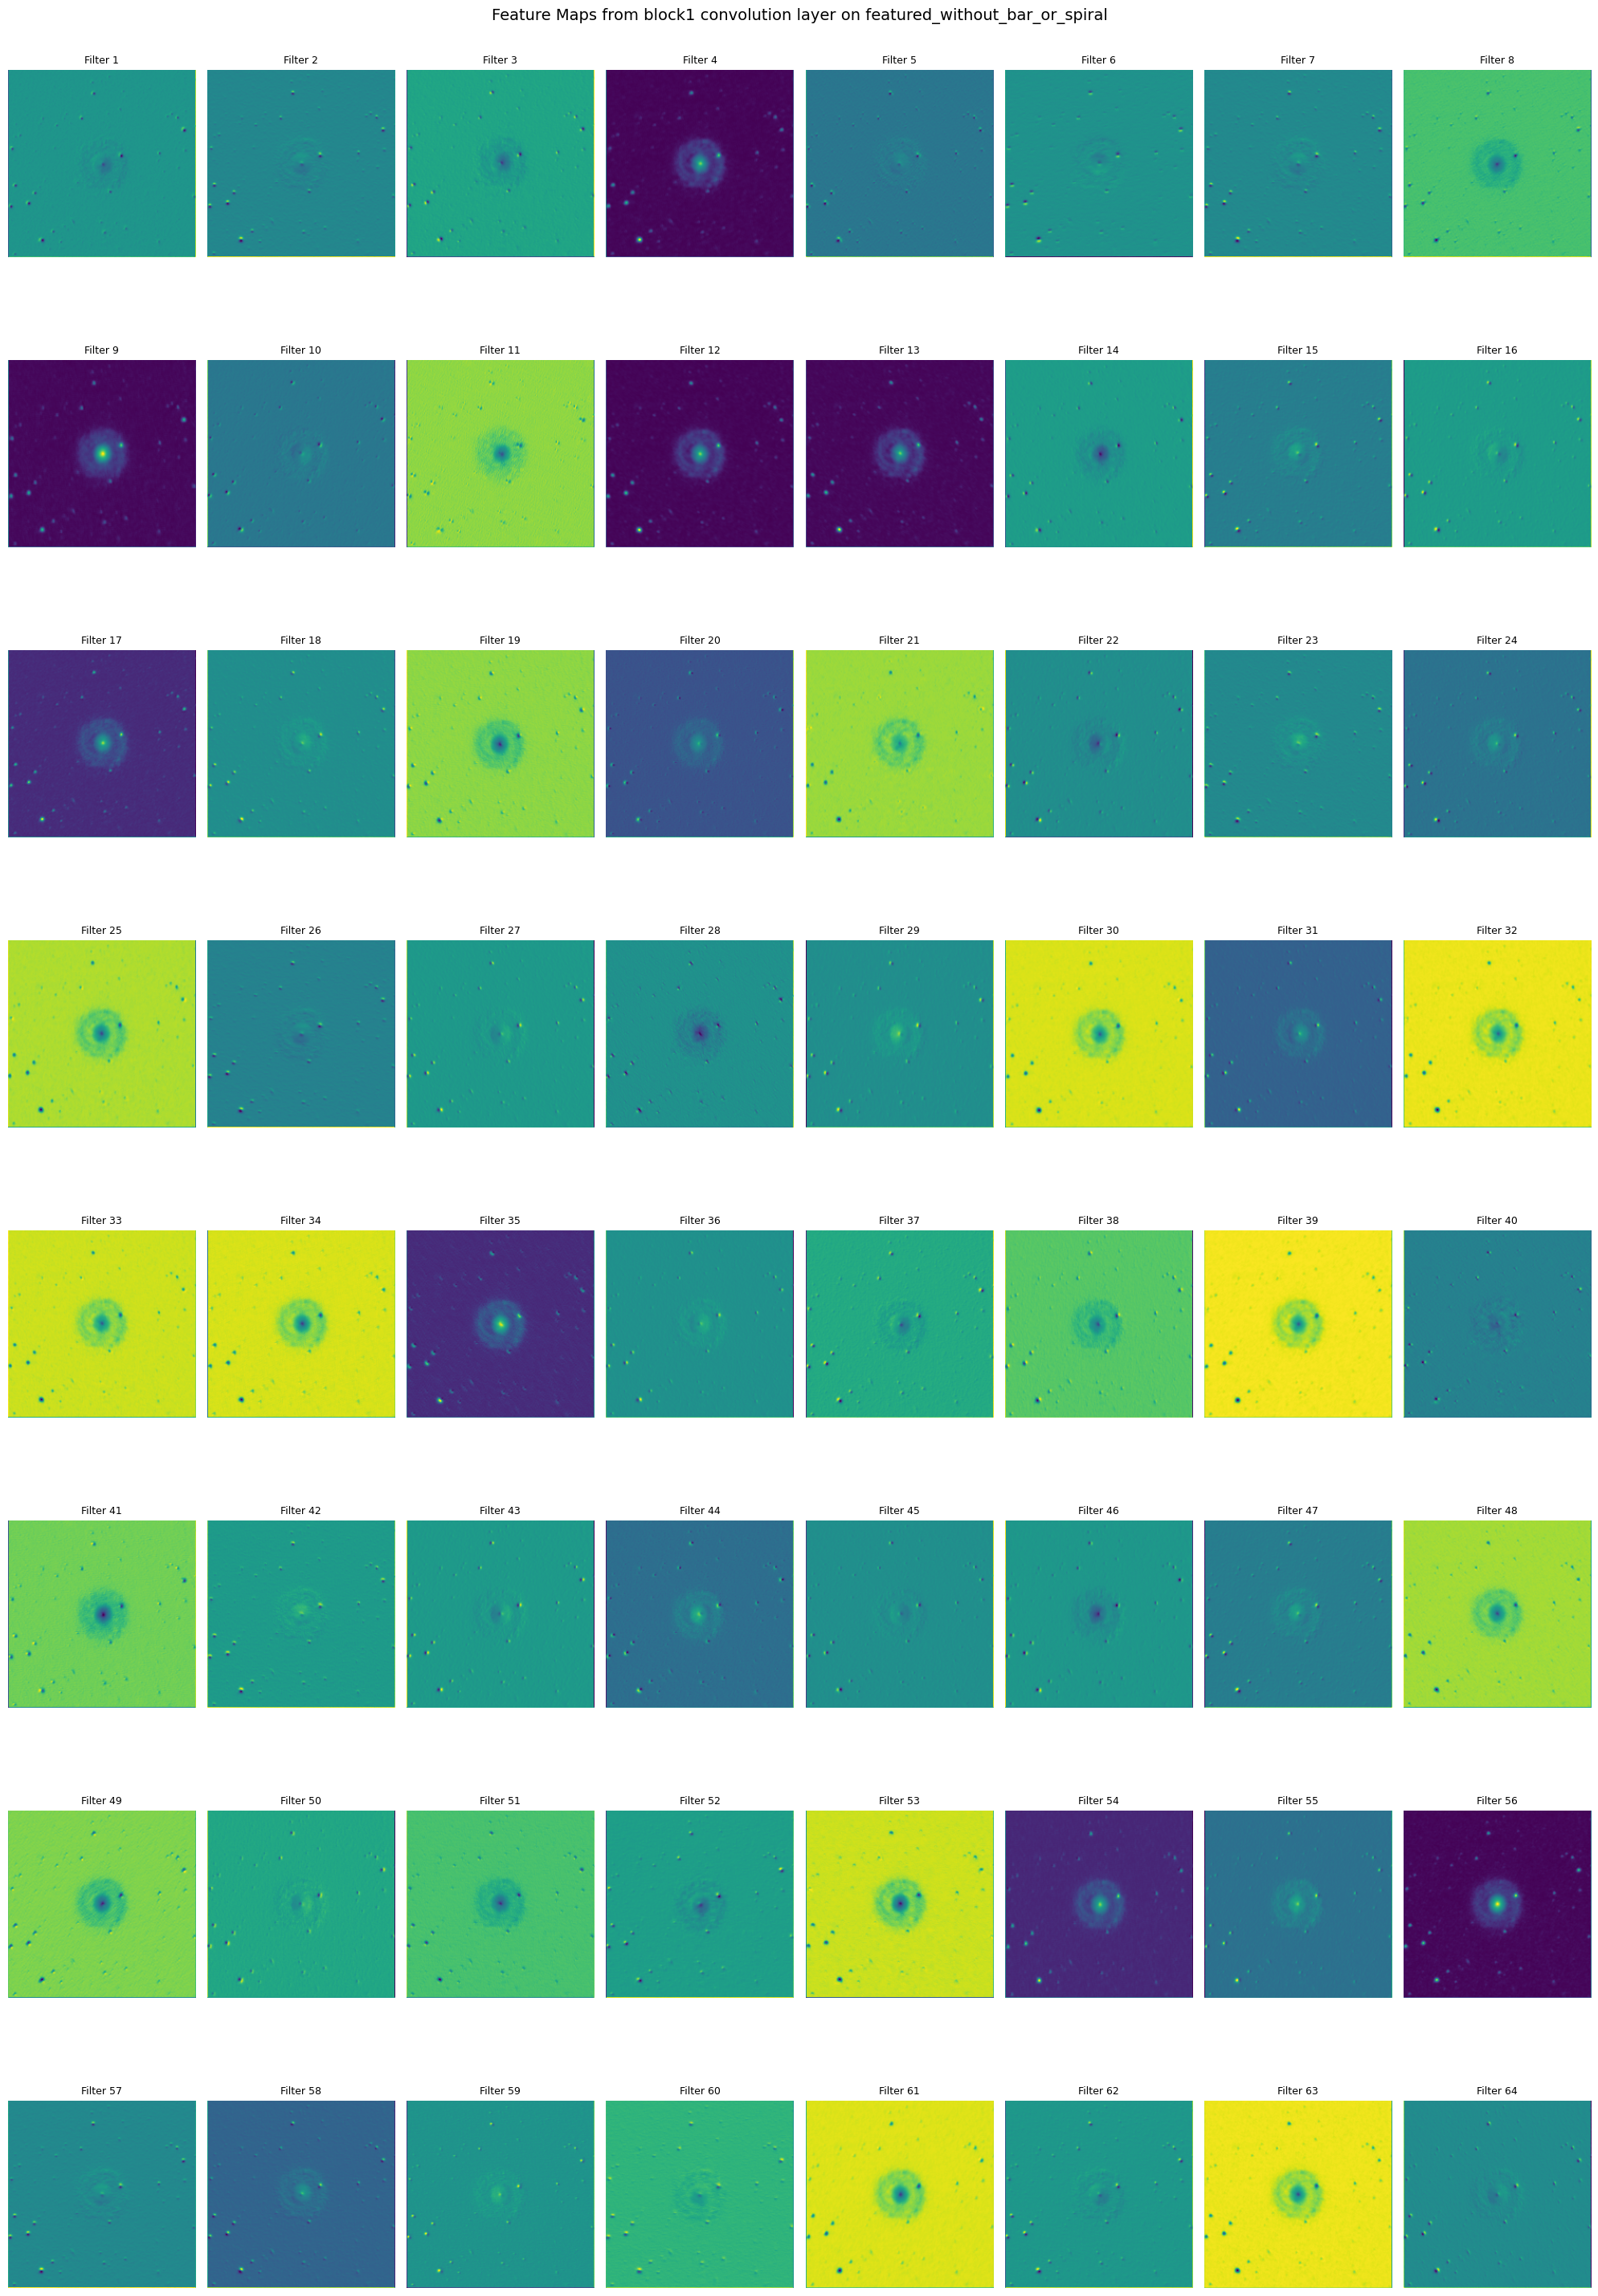


These feature maps show what patterns the CNN learned to detect!
Notice how different filters respond to different parts of the image.


In [52]:
def visualize_feature_maps(model, image):
    """
    Visualize feature maps from a specific layer
    """
    model.eval()
    
    layer = model.block1[0]
    
    feature_maps = []
    def hook_fn(module, input, output):
        feature_maps.append(output)
    
    hook = layer.register_forward_hook(hook_fn)
    
    with torch.no_grad():
        _ = model(image.unsqueeze(0).to(device))
    
    hook.remove()
    
    fm = feature_maps[0].squeeze().cpu().numpy()
    num_filters = fm.shape[0]
    
    n_filters_to_show = min(64, num_filters)
    cols = 8
    rows = (n_filters_to_show + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 30), layout='tight')
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n_filters_to_show):
        row, col = i // cols, i % cols
        axes[row, col].imshow(fm[i], cmap='viridis')
        axes[row, col].set_title(f'Filter {i+1}', fontsize=9)
        axes[row, col].axis('off')
    
    plt.suptitle(f'Feature Maps from block1 convolution layer on {idx_to_label[sample_label.cpu().item()]}', fontsize=14)
    plt.tight_layout()
    plt.show()

index = np.random.randint(0, len(test_dataset_modified))
sample_img, sample_label = test_dataset_modified[index]['image'], test_dataset_modified[index]['label']
visualize_feature_maps(model, sample_img)

print("\nThese feature maps show what patterns the CNN learned to detect!")
print("Notice how different filters respond to different parts of the image.")
